In [174]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [12]:
df = pd.read_csv('supermarket_sales_data_project/supermarket_sales.csv')
df.head(10)


,Invoice_ID,Branch,City,Customer_type,Gender,Product_line,Unit_price,Quantity,Tax,Total,Date,Time,Payment,cogs,gross_margin percentage,gross_income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3
5,699-14-3026,C,Naypyitaw,Normal,Male,Electronic accessories,85.39,7,29.8865,627.6165,3/25/2019,18:30,Ewallet,597.73,4.761905,29.8865,4.1
6,355-53-5943,A,Yangon,Member,Female,Electronic accessories,68.84,6,20.6520,433.6920,2/25/2019,14:36,Ewallet,413.04,4.761905,20.6520,5.8
7,315-22-5665,C,Naypyitaw,Normal,Female,Home and lifestyle,73.56,10,36.7800,772.3800,2/24/2019,11:38,Ewallet,735.60,4.761905,36.7800,8.0
8,665-32-9167,A,Yangon,Member,Female,Health and beauty,36.26,2,3.6260,76.1460,1/10/2019,17:15,Credit card,72.52,4.761905,3.6260,7.2
9,692-92-5582,B,Mandalay,Member,Female,Food and beverages,54.84,3,8.2260,172.7460,2/20/2019,13:27,Credit card,164.52,4.761905,8.2260,5.9


In [244]:
min = df['Date'].min()
max = df['Date'].max()
print(min,max)


1/1/2019 3/9/2019


In [99]:
product_lines = pd.DataFrame({'Gross_income':df.groupby('Product_line')['gross_income'].sum(),
                              'Sales_Count':df['Product_line'].value_counts()})
product_lines

,Gross_income,Sales_Count
Product_line,,
Electronic accessories,2587.5015,170
Fashion accessories,2585.9950,178
Food and beverages,2673.5640,174
Health and beauty,2342.5590,152
Home and lifestyle,2564.8530,160
Sports and travel,2624.8965,166


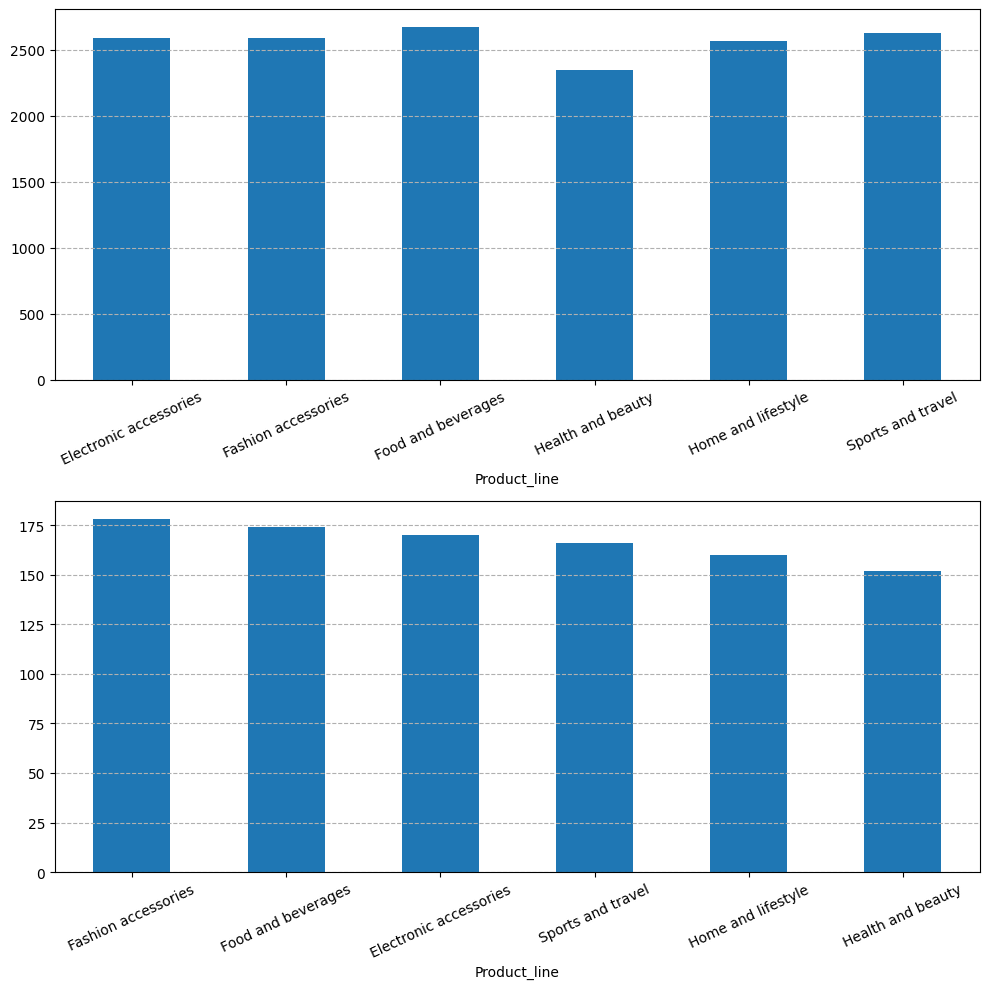

In [95]:
plt.figure(figsize=(10,10))

plt.subplot(2,1,1)
df.groupby('Product_line')['gross_income'].sum().plot(kind='bar')
plt.tick_params(axis='x',rotation=25)
plt.grid(axis='y',linestyle='--')

plt.subplot(2,1,2)
df['Product_line'].value_counts().plot(kind='bar')
plt.tick_params(axis='x',rotation=25)
plt.grid(axis='y',linestyle='--')

plt.tight_layout()
plt.show()

In [105]:
members_sales = pd.DataFrame({'gross_income':df.groupby('Customer_type')['gross_income'].sum(),
                             'count':df['Customer_type'].value_counts()})
members_sales

,gross_income,count
Customer_type,,
Member,7820.164,501
Normal,7559.205,499


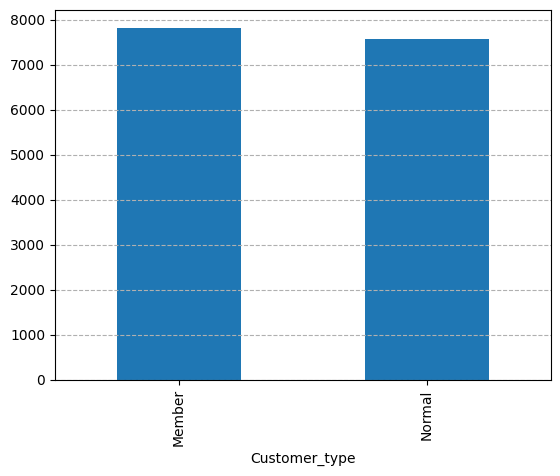

In [110]:
members_sales['gross_income'].plot(kind='bar')
plt.grid(axis='y',linestyle='--')

In [115]:
members_sales['average_spend'] = df.groupby('Customer_type')['gross_income'].mean()
members_sales

,gross_income,count,average_spend
Customer_type,,,
Member,7820.164,501,15.609110
Normal,7559.205,499,15.148707


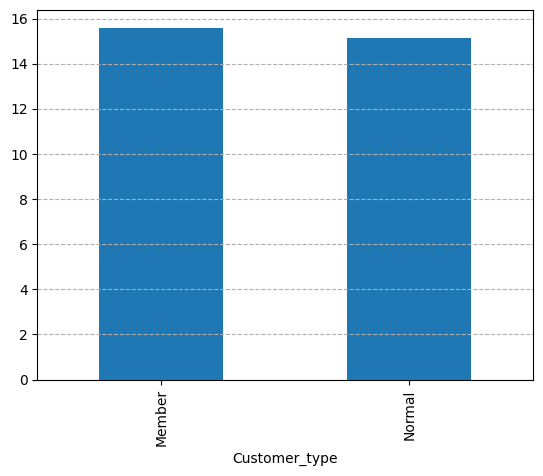

In [116]:
members_sales['average_spend'].plot(kind='bar')
plt.grid(axis='y',linestyle='--')

In [120]:
gender_members = pd.DataFrame({'Gross_income':df.groupby(['Customer_type','Gender'])['gross_income'].sum(),
                              'count':df[['Customer_type','Gender']].value_counts(),
                              'avg_gross_income':df.groupby(['Customer_type','Gender'])['gross_income'].mean()})
gender_members

Gross_income  count  avg_gross_income
Customer_type Gender                                       
Member        Female     4197.4735    261         16.082274
              Male       3622.6905    240         15.094544
Normal        Female     3796.9515    240         15.820631
              Male       3762.2535    259         14.526075

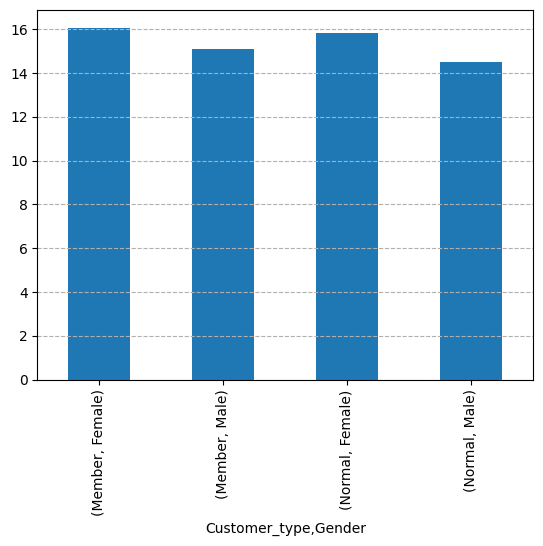

In [121]:
gender_members['avg_gross_income'].plot(kind='bar')
plt.grid(axis='y',linestyle='--')

In [123]:
city_sales = pd.DataFrame({'gross_income':df.groupby('City')['gross_income'].sum(),
                           'count':df['City'].value_counts(),
                           'avg_gross_income':df.groupby('City')['gross_income'].mean()})
city_sales

,gross_income,count,avg_gross_income
City,,,
Mandalay,5057.0320,332,15.232024
Naypyitaw,5265.1765,328,16.052367
Yangon,5057.1605,340,14.874001


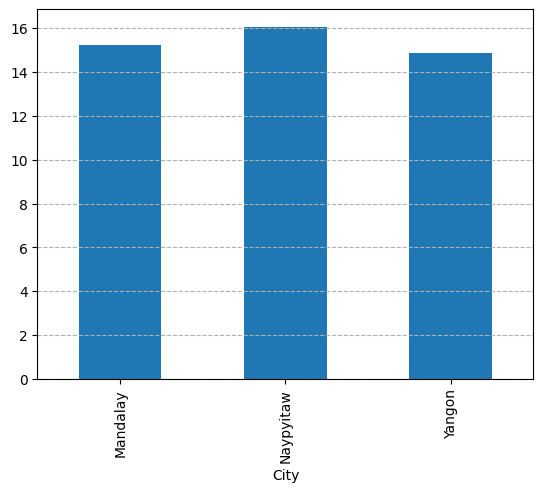

In [124]:
city_sales['avg_gross_income'].plot(kind='bar')
plt.grid(axis='y',linestyle='--')

In [126]:
gender_product_sales = pd.DataFrame({
    'count':df[['Gender','Product_line']].value_counts(),
    'gross_revenue':df.groupby(['Gender','Product_line'])['gross_income'].sum(),
    'avg_gross_revenue':df.groupby(['Gender','Product_line'])['gross_income'].mean()
})
gender_product_sales

count  gross_revenue  avg_gross_revenue
Gender Product_line                                                   
Female Electronic accessories     84      1290.5725          15.363958
       Fashion accessories        96      1449.4000          15.097917
       Food and beverages         90      1579.5675          17.550750
       Health and beauty          64       883.8565          13.810258
       Home and lifestyle         79      1430.3275          18.105411
       Sports and travel          88      1360.7010          15.462511
Male   Electronic accessories     86      1296.9290          15.080570
       Fashion accessories        82      1136.5950          13.860915
       Food and beverages         84      1093.9965          13.023768
       Health and beauty          88      1458.7025          16.576165
       Home and lifestyle         81      1134.5255          14.006488
       Sports and travel          78      1264.1955          16.207635

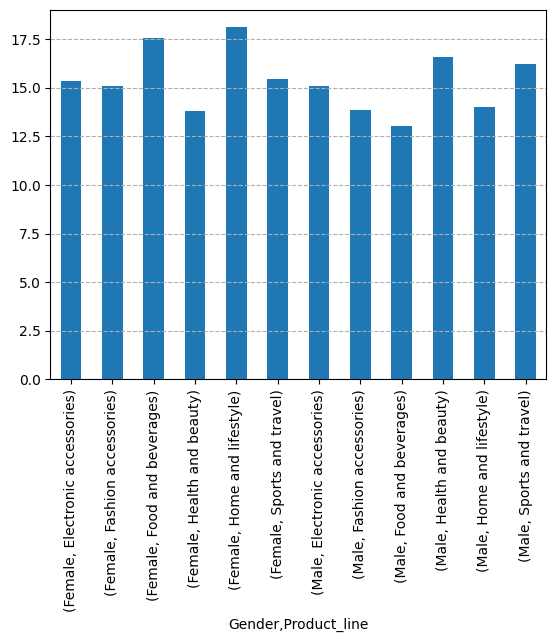

In [128]:
gender_product_sales['avg_gross_revenue'].plot(kind='bar')
plt.grid(axis='y',linestyle='--')

In [135]:
df.head(2)

,Invoice_ID,Branch,City,Customer_type,Gender,Product_line,Unit_price,Quantity,Tax,Total,Date,Time,Payment,cogs,gross_margin percentage,gross_income,Rating,product_cost
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1,74.69
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6,15.28


In [134]:
df['product_cost'] = df['cogs'] / df['Quantity']


In [136]:
df.groupby('City')['product_cost'].mean()

City
Mandalay     55.659277
Naypyitaw    56.609024
Yangon       54.780853
Name: product_cost, dtype: float64

In [139]:
df.groupby('City')['Rating'].mean()

City
Mandalay     6.818072
Naypyitaw    7.072866
Yangon       7.027059
Name: Rating, dtype: float64

In [142]:
df.groupby(['City','Customer_type'])['Gender'].value_counts()

City       Customer_type  Gender
Mandalay   Member         Female    85
                          Male      80
           Normal         Male      90
                          Female    77
Naypyitaw  Member         Female    96
                          Male      73
           Normal         Female    82
                          Male      77
Yangon     Member         Male      87
                          Female    80
           Normal         Male      92
                          Female    81
Name: count, dtype: int64

In [143]:
df.groupby('City')['Gender'].value_counts()

City       Gender
Mandalay   Male      170
           Female    162
Naypyitaw  Female    178
           Male      150
Yangon     Male      179
           Female    161
Name: count, dtype: int64

([<matplotlib.axis.YTick at 0x23343a7cfd0>,
 [Text(0, 0, '0'),
  Text(0, 250, '250'),
  Text(0, 500, '500'),
  Text(0, 750, '750'),
  Text(0, 1000, '1000'),
  Text(0, 1250, '1250'),
  Text(0, 1500, '1500'),
  Text(0, 1750, '1750'),
  Text(0, 2000, '2000'),
  Text(0, 2250, '2250'),
  Text(0, 2500, '2500'),
  Text(0, 2750, '2750')])

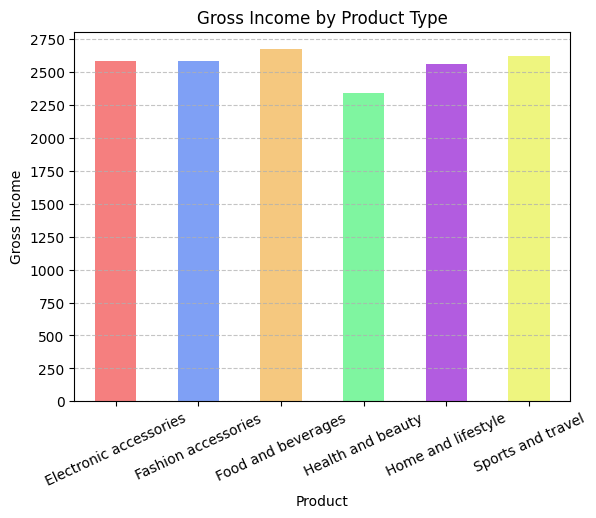

In [176]:
df.groupby('Product_line')['gross_income'].sum().plot(kind='bar',color=['#F57F7F','#7FA0F5','#F5C87F','#7FF5A0','#B25CE0','#EEF57F'])
plt.tick_params(axis='x',rotation=25)
plt.grid(axis='y',linestyle='--',alpha=0.75)
plt.ylabel('Gross Income')
plt.xlabel('Product')
plt.title('Gross Income by Product Type')
plt.yticks(np.arange(0,3000,250))


Text(0.5, 1.0, 'Amount of Products Sold by Product Type')

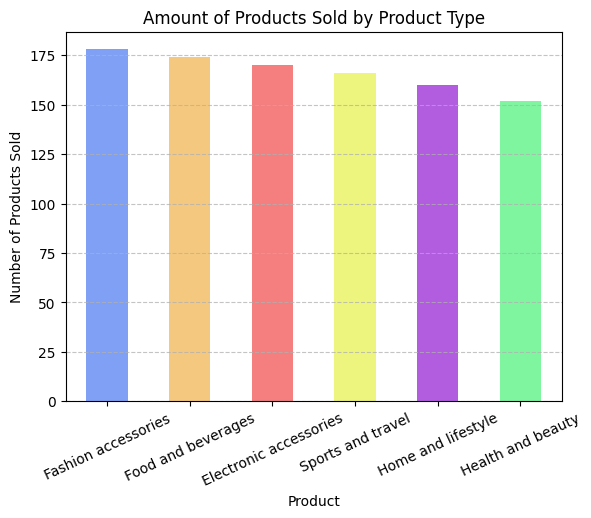

In [187]:
df['Product_line'].value_counts().plot(kind='bar',color=['#7FA0F5','#F5C87F','#F57F7F','#EEF57F','#B25CE0','#7FF5A0'])
plt.tick_params(axis='x',rotation=25)
plt.grid(axis='y',linestyle='--',alpha=0.75)
plt.ylabel('Number of Products Sold')
plt.xlabel('Product')
plt.title('Amount of Products Sold by Product Type')

Text(0.5, 1.0, 'Member vs Non-Member Gross Income')

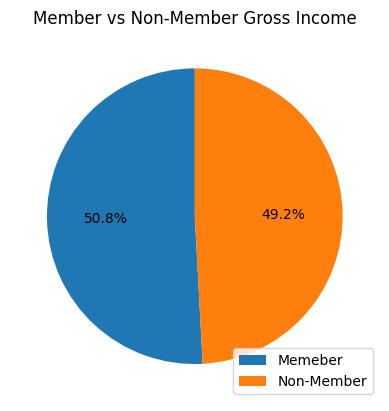

In [195]:
wedges, texts, autotexts = plt.pie(
    gender_members.groupby('Customer_type')['Gross_income'].sum(),
    autopct='%1.1f%%',
    startangle=90
)
plt.legend(wedges,['Memeber','Non-Member'],loc='best')
plt.title('Member vs Non-Member Gross Income')

Text(0.5, 1.0, 'Member vs Non-Member and Gender')

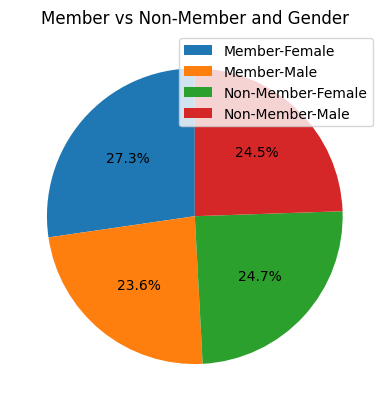

In [203]:
wedges, texts, autotexts = plt.pie(
    gender_members.groupby(['Customer_type','Gender'])['Gross_income'].sum(),
    autopct='%1.1f%%',
    startangle=90
)
plt.legend(wedges,['Member-Female','Member-Male','Non-Member-Female','Non-Member-Male'],loc='upper right')
plt.title('Member vs Non-Member and Gender')

In [204]:
city_sales = pd.DataFrame({'gross_income':df.groupby('City')['gross_income'].sum(),
                           'count':df['City'].value_counts(),
                           'avg_gross_income':df.groupby('City')['gross_income'].mean()})
city_sales

,gross_income,count,avg_gross_income
City,,,
Mandalay,5057.0320,332,15.232024
Naypyitaw,5265.1765,328,16.052367
Yangon,5057.1605,340,14.874001


([<matplotlib.axis.YTick at 0x233462b5b50>,
 [Text(0, 0, '0'),
  Text(0, 500, '500'),
  Text(0, 1000, '1000'),
  Text(0, 1500, '1500'),
  Text(0, 2000, '2000'),
  Text(0, 2500, '2500'),
  Text(0, 3000, '3000'),
  Text(0, 3500, '3500'),
  Text(0, 4000, '4000'),
  Text(0, 4500, '4500'),
  Text(0, 5000, '5000')])

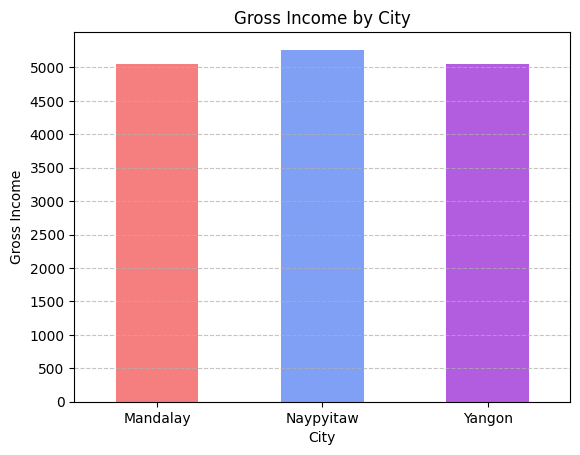

In [216]:
city_sales.groupby('City')['gross_income'].sum().plot(kind='bar',color=['#F57F7F','#7FA0F5','#B25CE0'])
plt.grid(axis='y',linestyle='--',alpha=0.75)
plt.xlabel('City')
plt.ylabel('Gross Income')
plt.tick_params(axis='x',rotation=0)
plt.title('Gross Income by City')
plt.yticks(np.arange(0,5500,500))

([<matplotlib.axis.YTick at 0x23347885550>,
 [Text(0, 0, '0'),
  Text(0, 10, '10'),
  Text(0, 20, '20'),
  Text(0, 30, '30'),
  Text(0, 40, '40'),
  Text(0, 50, '50'),
  Text(0, 60, '60'),
  Text(0, 70, '70'),
  Text(0, 80, '80'),
  Text(0, 90, '90')])

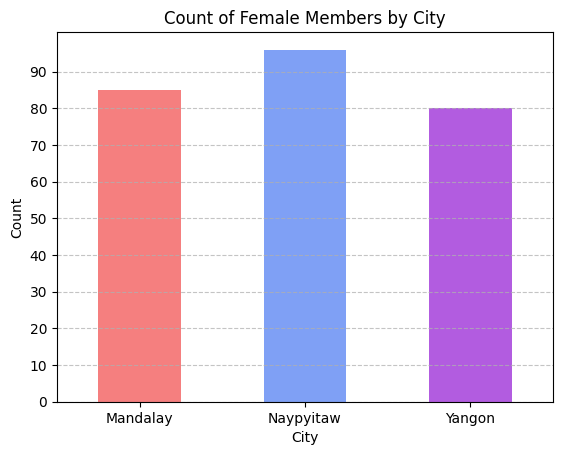

In [238]:
df[(df['Gender']=='Female') & (df['Customer_type'] == 'Member')].groupby(['City'])['Gender'].value_counts().plot(kind='bar', color=['#F57F7F','#7FA0F5','#B25CE0'])
plt.tick_params(axis='x',rotation=0)
plt.xticks(ticks=range(3),labels=['Mandalay','Naypyitaw','Yangon'])
plt.ylabel('Count')
plt.xlabel('City')
plt.title('Count of Female Members by City')
plt.grid(axis='y',linestyle='--',alpha=0.75)
plt.yticks(np.arange(0,100,10))